# Import Modules

In [79]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

# Load Dataset

In [80]:
hyperspectral_path = "../Dataset/indianpinearray.npy"  
label_path = "../Dataset/IPgt.npy"  

In [81]:
H = np.load(hyperspectral_path)   
GT = np.load(label_path)         

In [82]:
print(f"Shape of Hyperspectral Image: {H.shape}")
print(f"Shape of Labels: {GT.shape}")

Shape of Hyperspectral Image: (145, 145, 200)
Shape of Labels: (145, 145)


In [83]:
H

array([[[3172, 4142, 4506, ..., 1057, 1020, 1020],
        [2580, 4266, 4502, ..., 1064, 1029, 1020],
        [3687, 4266, 4421, ..., 1061, 1030, 1016],
        ...,
        [2570, 3890, 4320, ..., 1042, 1021, 1015],
        [3170, 4130, 4320, ..., 1054, 1024, 1020],
        [3172, 3890, 4316, ..., 1043, 1034, 1016]],

       [[2576, 4388, 4334, ..., 1047, 1030, 1006],
        [2747, 4264, 4592, ..., 1055, 1039, 1015],
        [2750, 4268, 4423, ..., 1047, 1026, 1015],
        ...,
        [3859, 4512, 4605, ..., 1056, 1035, 1015],
        [3686, 4264, 4690, ..., 1051, 1012, 1020],
        [2744, 4268, 4597, ..., 1047, 1019, 1016]],

       [[2744, 4146, 4416, ..., 1055, 1029, 1025],
        [2576, 4389, 4416, ..., 1051, 1021, 1011],
        [2744, 4273, 4420, ..., 1068, 1033, 1010],
        ...,
        [2570, 4266, 4509, ..., 1051, 1025, 1010],
        [2576, 4262, 4496, ..., 1047, 1029, 1020],
        [2742, 4142, 4230, ..., 1042, 1025, 1011]],

       ...,

       [[3324, 3728, 400

In [84]:
GT

array([[3, 3, 3, ..., 0, 0, 0],
       [3, 3, 3, ..., 0, 0, 0],
       [3, 3, 3, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(145, 145), dtype=uint8)

# Visual checks 
Plotting a few bands and the label image

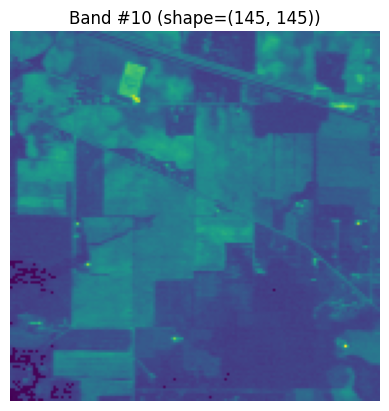

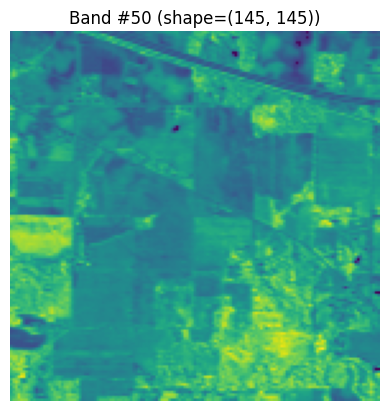

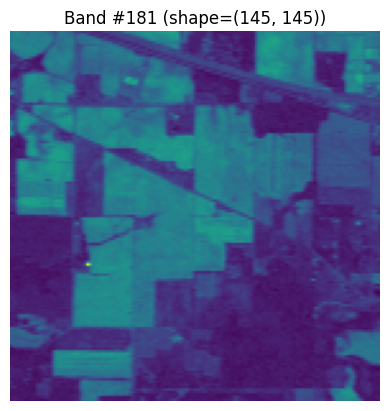

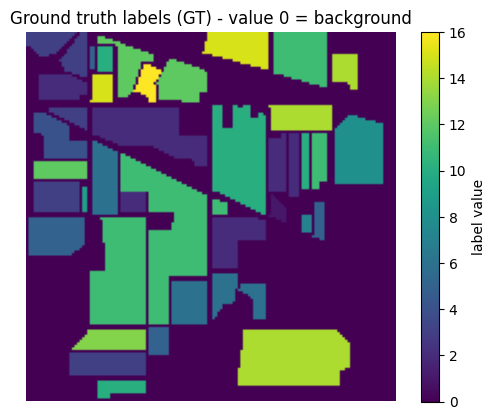

In [85]:
def show_band(band_index, cmap='gray'):
    """Display a single spectral band as an image."""
    assert 0 <= band_index < H.shape[2], "band_index out of range"
    plt.imshow(H[:, :, band_index])
    plt.title(f"Band #{band_index} (shape={H.shape[:2]})")
    plt.axis('off')
    plt.show()

# show a few sample bands (choose indices in-range)
sample_bands = [10, 50, 181]   # change these indices if you want
for b in sample_bands:
    show_band(b)

# show the label map (colors will be auto-chosen)
plt.imshow(GT)
plt.title("Ground truth labels (GT) - value 0 = background")
plt.colorbar(label='label value')
plt.axis('off')
plt.show()

In [ ]:
r, c = 10, 15   # example pixel coordinates (row, col)
spectrum = H[r, c, :]
label_at_pixel = GT[r, c]
print(f"\nSample pixel at (row={r}, col={c}): label = {int(label_at_pixel)}")
print("Spectrum (200 band values):\n", spectrum[:])


Sample pixel at (row=10, col=15): label = 3
Spectrum (200 band values):
 [2736 4387 4502 4550 5004 5235 5324 5264 5222 4989 5054 4955 4826 5013
 5103 5080 5004 4861 4773 4664 4655 4697 4590 4506 4535 4479 4360 4445
 4473 4150 4277 4103 4345 4635 4541 4492 5128 5509 5395 3812 5518 5589
 5458 5313 4929 4563 4795 5144 5045 5144 5074 5023 5007 4181 3962 3849
 2730 2223 2344 2594 3243 3814 4219 4459 4349 4364 4322 4282 4249 4209
 4036 4009 3893 3782 2603 2796 1724 1626 1843 1755 2295 2839 2929 2911
 2985 2981 3081 3140 3206 3174 3032 2798 2823 3001 2759 2946 2931 2765
 2516 2267 1853 1559 1079 1045 1068 1105 1130 1247 1364 1274 1372 1639
 1871 2030 2139 2203 2239 2250 2240 2115 2136 2163 2124 2113 2152 2158
 2092 2090 2087 2035 2016 1987 1945 1889 1863 1795 1746 1714 1653 1547
 1425 1294 1144 1044 1031 1045 1103 1218 1291 1237 1088 1103 1215 1347
 1335 1253 1264 1312 1371 1395 1397 1393 1391 1392 1378 1362 1342 1338
 1328 1320 1307 1327 1328 1310 1303 1285 1266 1262 1250 1230 1225 1222
 12

# Data Preprocessing

In [87]:
# H (hyperspectral cube) and GT (ground-truth labels) are already loaded

# ---------- Config ----------
NORMALIZATION = "standard"   # options: "standard" or "minmax"
# ----------------------------

In [88]:
print("Original shapes: H =", H.shape, ", GT =", GT.shape)

# 1) Flatten spatial dimensions -> samples x bands
H_flat = H.reshape(-1, H.shape[2])   # shape: (145*145, 200) -> (21025, 200)
GT_flat = GT.reshape(-1)             # shape: (21025,)

print("After flattening: H_flat.shape =", H_flat.shape, ", GT_flat.shape =", GT_flat.shape)

# 2) Remove background pixels (label == 0)
mask = GT_flat != 0
X = H_flat[mask]
y = GT_flat[mask]

print("After removing background (label=0):")
print("  usable samples:", X.shape[0])
print("  number of features (bands):", X.shape[1])
print("  unique labels (should be 1..16):", np.unique(y))

Original shapes: H = (145, 145, 200) , GT = (145, 145)
After flattening: H_flat.shape = (21025, 200) , GT_flat.shape = (21025,)
After removing background (label=0):
  usable samples: 10249
  number of features (bands): 200
  unique labels (should be 1..16): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [89]:
# Convert to float

X = X.astype(np.float32)

if NORMALIZATION == "standard":
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Applied StandardScaler (zero-mean, unit-variance).")
elif NORMALIZATION == "minmax":
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler.fit_transform(X)
    print("Applied MinMaxScaler (scaled to [0,1]).")
else:
    raise ValueError("NORMALIZATION must be 'standard' or 'minmax'")

Applied StandardScaler (zero-mean, unit-variance).



Class distribution (label: count) after removing background:
   1 : 46
   2 : 1428
   3 : 830
   4 : 237
   5 : 483
   6 : 730
   7 : 28
   8 : 478
   9 : 20
  10 : 972
  11 : 2455
  12 : 593
  13 : 205
  14 : 1265
  15 : 386
  16 : 93


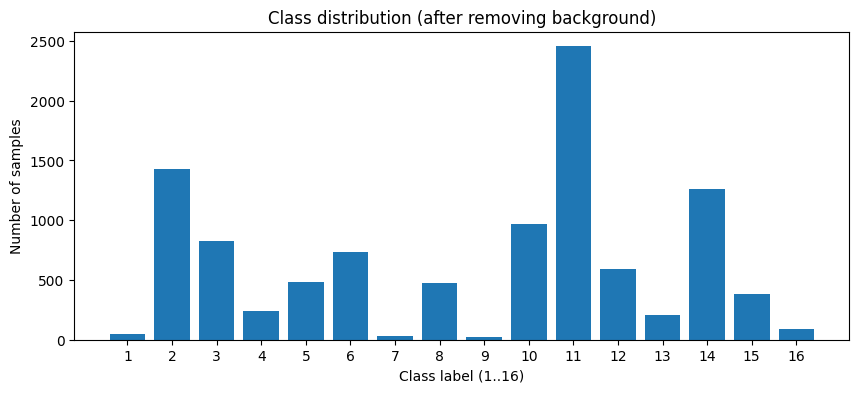

In [90]:
# 4) Show class distribution (counts) before and after 
label_counts = Counter(y)
print("\nClass distribution (label: count) after removing background:")
for lab in sorted(label_counts):
    print(f"  {lab:2d} : {label_counts[lab]}")

# Visualize class distribution as bar chart
plt.figure(figsize=(10,4))
labels_sorted = sorted(label_counts.keys())
counts_sorted = [label_counts[l] for l in labels_sorted]
plt.bar(labels_sorted, counts_sorted)
plt.xlabel("Class label (1..16)")
plt.ylabel("Number of samples")
plt.title("Class distribution (after removing background)")
plt.xticks(labels_sorted)
plt.show()

In [91]:
# 6) Save preprocessed arrays in memory for next steps (train/test split, feature selection etc.)
X_preprocessed = X_scaled    # features ready for modeling
y_preprocessed = y

# Print final summary
print("\nPreprocessing complete.")
print("X_preprocessed shape:", X_preprocessed.shape)
print("y_preprocessed shape:", y_preprocessed.shape)


Preprocessing complete.
X_preprocessed shape: (10249, 200)
y_preprocessed shape: (10249,)


#  Stratified Train-Test Split

In [92]:
# Config
TEST_SIZE = 0.20    # 20% test, 80% train 
RANDOM_STATE = 42

# Quick checks
X = X_preprocessed
y = y_preprocessed
assert X.shape[0] == y.shape[0], "Number of samples in X and y must match."

In [93]:
# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Diagnostics
print("\n--- Split summary ---")
print("Total samples:", X.shape[0])
print("Train samples:", X_train.shape[0])
print("Test  samples:", X_test.shape[0])
print("\nTrain shape:", X_train.shape)
print("Test  shape:", X_test.shape)


--- Split summary ---
Total samples: 10249
Train samples: 8199
Test  samples: 2050

Train shape: (8199, 200)
Test  shape: (2050, 200)


In [94]:
# Show class distribution before and after split
def print_dist(prefix, labels):
    cnt = Counter(labels)
    items = sorted(cnt.items())
    print(f"\n{prefix} (label: count):")
    for lab, c in items:
        print(f"  {lab:2d} : {c}")

print_dist("Original (after preprocessing)", y)
print_dist("Train", y_train)
print_dist("Test", y_test)


Original (after preprocessing) (label: count):
   1 : 46
   2 : 1428
   3 : 830
   4 : 237
   5 : 483
   6 : 730
   7 : 28
   8 : 478
   9 : 20
  10 : 972
  11 : 2455
  12 : 593
  13 : 205
  14 : 1265
  15 : 386
  16 : 93

Train (label: count):
   1 : 37
   2 : 1142
   3 : 664
   4 : 190
   5 : 386
   6 : 584
   7 : 23
   8 : 382
   9 : 16
  10 : 778
  11 : 1964
  12 : 474
  13 : 164
  14 : 1012
  15 : 309
  16 : 74

Test (label: count):
   1 : 9
   2 : 286
   3 : 166
   4 : 47
   5 : 97
   6 : 146
   7 : 5
   8 : 96
   9 : 4
  10 : 194
  11 : 491
  12 : 119
  13 : 41
  14 : 253
  15 : 77
  16 : 19


In [95]:
print(f"X_Train max value: {X_train.max()}")
print(f"X_Train min value: {X_train.min()}\n")
print(f"X_Test max value: {X_test.max()}")
print(f"X_Test min value: {X_test.min()}")

X_Train max value: 7.009053707122803
X_Train min value: -8.0457181930542

X_Test max value: 4.857397079467773
X_Test min value: -6.344175815582275


# Baseline Decision Tree Classifier (No Band Selection)

In [96]:
# 1. Train Decision Tree on all 200 bands

model_dt = DecisionTreeClassifier(
    criterion='gini',        
    max_depth=25,            
    min_samples_split=2,
    random_state=42
)

In [97]:
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [98]:
# 2. Make predictions

y_pred = model_dt.predict(X_test)


Baseline Decision Tree Accuracy: 74.63%

Classification Report:
              precision    recall  f1-score   support

           1      0.625     0.556     0.588         9
           2      0.650     0.643     0.647       286
           3      0.549     0.602     0.575       166
           4      0.566     0.638     0.600        47
           5      0.941     0.825     0.879        97
           6      0.903     0.890     0.897       146
           7      0.600     0.600     0.600         5
           8      0.922     0.979     0.949        96
           9      0.600     0.750     0.667         4
          10      0.684     0.680     0.682       194
          11      0.764     0.752     0.758       491
          12      0.618     0.571     0.594       119
          13      0.927     0.927     0.927        41
          14      0.909     0.913     0.911       253
          15      0.541     0.597     0.568        77
          16      1.000     0.895     0.944        19

    accuracy   

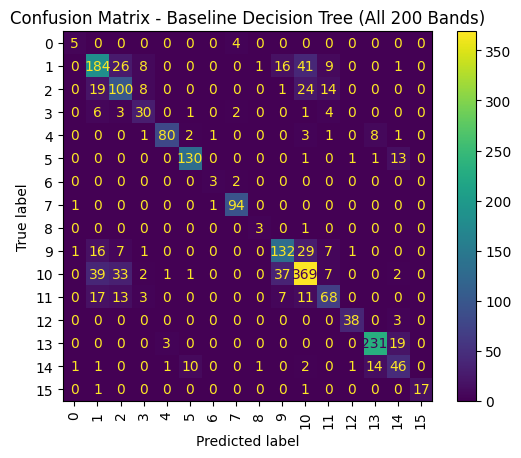

In [ ]:
# 3. Evaluate performance
acc = accuracy_score(y_test, y_pred)
print(f"\nBaseline Decision Tree Accuracy: {acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title("Confusion Matrix - Baseline Decision Tree (All 200 Bands)")
plt.show()

In [100]:
model_dt.get_depth()

25

# EMBEDDED FEATURE SELECTION (Decision Tree feature_importances_)

In [ ]:
# CONFIG: which k values to test
# k_list = [n for i in range (100)]  
k_list = [5, 10, 20, 30,40, 50]  

# Using same hyperparameters as baseline for fair comparison
dt_params = {
    "criterion": model_dt.criterion if hasattr(model_dt, "criterion") else "entropy",
    "max_depth": model_dt.max_depth if hasattr(model_dt, "max_depth") else None,
    "min_samples_split": model_dt.min_samples_split if hasattr(model_dt, "min_samples_split") else 2,
    "random_state": 42
}

In [102]:
# 1) Get feature importances from the baseline model
importances = model_dt.feature_importances_
if importances is None or importances.sum() == 0:
    raise ValueError("Feature importances from the baseline model are empty or zero. "
                     "Ensure the baseline model is trained and has non-zero importances.")

In [103]:
# 2) Rank bands by importance (descending)
ranked_idx = np.argsort(importances)[::-1]   # indices of bands sorted by importance (most -> least)
ranked_importances = importances[ranked_idx]

print("Top 20 bands by importance (index : importance):")
for i in range(min(20, len(ranked_idx))):
    print(f"  {ranked_idx[i]:3d} : {ranked_importances[i]:.6f}")

Top 20 bands by importance (index : importance):
   31 : 0.121052
  181 : 0.083913
  101 : 0.047562
   58 : 0.033406
   34 : 0.028823
   83 : 0.022939
  147 : 0.020340
   19 : 0.019650
    2 : 0.018558
   28 : 0.016839
    7 : 0.015414
  180 : 0.014452
  128 : 0.014051
   35 : 0.013548
   99 : 0.013310
    8 : 0.011675
  130 : 0.011297
  111 : 0.011170
   43 : 0.010787
  160 : 0.010307


In [104]:
# 3) Evaluate performance for each k
results = []
for k in k_list:
    if k > X_train.shape[1]:
        print(f"Skipping k={k} (more than available bands).")
        continue
    selected_bands = ranked_idx[:k]                # top-k band indices
    # Build reduced train/test sets
    Xtr_k = X_train[:, selected_bands]
    Xte_k = X_test[:, selected_bands]
    # Train a new Decision Tree with same params (for fair comparison)
    dt_k = DecisionTreeClassifier(**dt_params)
    dt_k.fit(Xtr_k, y_train)
    ypred_k = dt_k.predict(Xte_k)
    acc_k = accuracy_score(y_test, ypred_k)
    results.append({"k": k, "accuracy": acc_k, "model": dt_k, "selected_bands": selected_bands, "y_pred": ypred_k})
    print(f"\n[k={k}] Accuracy: {acc_k*100:.2f}%")
    print("Classification report (partial):")
    print(classification_report(y_test, ypred_k, digits=3, zero_division=0))


[k=5] Accuracy: 68.15%
Classification report (partial):
              precision    recall  f1-score   support

           1      0.400     0.444     0.421         9
           2      0.535     0.556     0.545       286
           3      0.519     0.500     0.509       166
           4      0.561     0.489     0.523        47
           5      0.852     0.773     0.811        97
           6      0.862     0.897     0.879       146
           7      0.750     0.600     0.667         5
           8      0.918     0.938     0.928        96
           9      0.600     0.750     0.667         4
          10      0.620     0.613     0.617       194
          11      0.700     0.680     0.690       491
          12      0.365     0.420     0.391       119
          13      0.867     0.951     0.907        41
          14      0.916     0.905     0.911       253
          15      0.500     0.506     0.503        77
          16      1.000     0.842     0.914        19

    accuracy           


Summary (k vs accuracy):
    k  accuracy
0   5  0.681463
1  10  0.718537
2  20  0.747317
3  30  0.766829
4  40  0.763902
5  50  0.762927


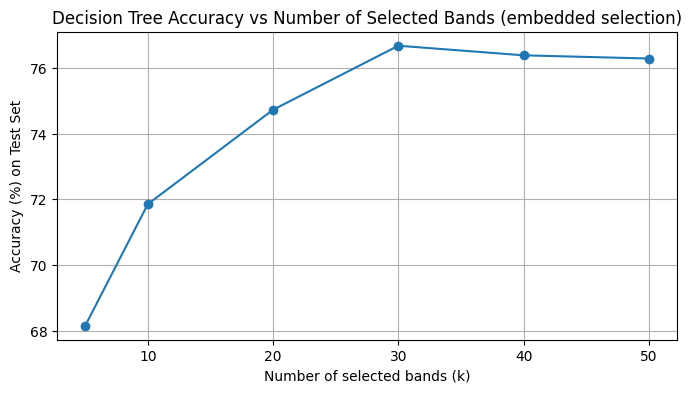

In [105]:
# 4) Summarize results in a DataFrame and plot
df_res = pd.DataFrame([{"k": r["k"], "accuracy": r["accuracy"]} for r in results]).sort_values("k")
print("\nSummary (k vs accuracy):")
print(df_res)

plt.figure(figsize=(8,4))
plt.plot(df_res["k"], df_res["accuracy"]*100, marker='o')
plt.xlabel("Number of selected bands (k)")
plt.ylabel("Accuracy (%) on Test Set")
plt.title("Decision Tree Accuracy vs Number of Selected Bands (embedded selection)")
plt.grid(True)
plt.show()

In [106]:
# 5) Pick the best k (highest accuracy). If ties, pick smallest k among ties (parsimony)
best_row = df_res.loc[df_res["accuracy"].idxmax()]
best_k = int(best_row["k"])
best_acc = float(best_row["accuracy"])
print(f"\nBest k found: {best_k} with accuracy {best_acc*100:.2f}%")

# Get the corresponding trained model and bands
best_entry = next(r for r in results if r["k"] == best_k)
best_model = best_entry["model"]
best_bands = best_entry["selected_bands"]
print("Selected band indices (top-k):", best_bands.tolist())


Best k found: 30 with accuracy 76.68%
Selected band indices (top-k): [31, 181, 101, 58, 34, 83, 147, 19, 2, 28, 7, 180, 128, 35, 99, 8, 130, 111, 43, 160, 114, 5, 126, 127, 27, 17, 23, 74, 137, 72]


<Figure size 1000x800 with 0 Axes>

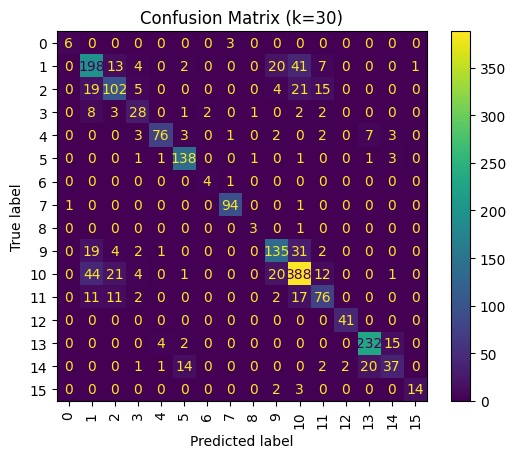

In [107]:
# 6) show confusion matrix for best model
cm = confusion_matrix(y_test, best_entry["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10,8))
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

# COMPARISON, RESULTS & ANALYSIS

In [108]:
# Performs: retraining time measures, overall test comparison, per-class metrics,
# confusion matrices side-by-side, reconstructed spatial maps of predictions

baseline_acc = acc

# Recompute best_k / best_model
best_row = df_res.loc[df_res['accuracy'].idxmax()]
best_k = int(best_row['k'])
best_entry = next(r for r in results if r['k'] == best_k)
best_model = best_entry['model']
best_bands = best_entry['selected_bands']

print(f"\nBaseline accuracy (test) : {baseline_acc*100:.2f}%")
print(f"Optimized (best k)       : {best_k} bands, accuracy: {best_model.score(X_test[:, best_bands], y_test)*100:.2f}%")


Baseline accuracy (test) : 74.63%
Optimized (best k)       : 30 bands, accuracy: 76.68%


In [109]:
# ----- Measure training/prediction time for baseline vs optimized -----

def time_fit_predict(model_cls, Xtr, ytr, Xte, n_repeat=3, **kwargs):
    # returns median fit-time, median predict-time, trained model
    fit_times, pred_times = [], []
    trained = None
    for _ in range(n_repeat):
        m = model_cls(**kwargs)
        t0 = time.time()
        m.fit(Xtr, ytr)
        t1 = time.time()
        _ = m.predict(Xte)
        t2 = time.time()
        fit_times.append(t1 - t0)
        pred_times.append(t2 - t1)
        trained = m
    return np.median(fit_times), np.median(pred_times), trained

print("\nMeasuring fit/predict times (median of 3 runs)...")
try:
    ft_base, pt_base, _ = time_fit_predict(
        type(model_dt), X_train, y_train, X_test,
        criterion=model_dt.criterion,
        max_depth=model_dt.max_depth,
        min_samples_split=model_dt.min_samples_split,
        random_state=42
    )

    ft_opt, pt_opt, _ = time_fit_predict(
        type(best_model), X_train[:, best_bands], y_train, X_test[:, best_bands],
        criterion=best_model.criterion,
        max_depth=best_model.max_depth,
        min_samples_split=best_model.min_samples_split,
        random_state=42
    )

    print(f"Baseline fit time (s): {ft_base:.4f}  predict time (s): {pt_base:.4f}")
    print(f"Optimized fit time (s): {ft_opt:.4f}  predict time (s): {pt_opt:.4f}")

    reduction_pct = (1 - (ft_opt / ft_base)) * 100 if ft_base > 0 else 0
    print(f"Fit time reduced by ~{reduction_pct:.1f}%")

except Exception as e:
    print("Timing failed:", e)


Measuring fit/predict times (median of 3 runs)...
Baseline fit time (s): 3.7435  predict time (s): 0.0020
Optimized fit time (s): 0.7410  predict time (s): 0.0021
Fit time reduced by ~80.2%


In [110]:
# ----- Per-class metrics for Test Set (comparison) -----
print("\nPer-class metrics on TEST SET (baseline vs optimized):")

# baseline predictions on test set
y_pred_base = model_dt.predict(X_test)
y_pred_opt = best_model.predict(X_test[:, best_bands])

# classification reports
print("\nBaseline model (all bands) - classification report:")
print(classification_report(y_test, y_pred_base, digits=3, zero_division=0))

print("\nOptimized model (top k bands) - classification report:")
print(classification_report(y_test, y_pred_opt, digits=3, zero_division=0))

# Build a DataFrame of per-class accuracy/precision/recall/F1 for both models
labels = np.unique(y_test)
p_base, r_base, f_base, _ = precision_recall_fscore_support(y_test, y_pred_base, labels=labels, zero_division=0)
p_opt, r_opt, f_opt, _ = precision_recall_fscore_support(y_test, y_pred_opt, labels=labels, zero_division=0)
support = np.array([(y_test == lab).sum() for lab in labels])

df_cmp = pd.DataFrame({
    "label": labels,
    "support": support,
    "base_precision": p_base, "base_recall": r_base, "base_f1": f_base,
    "opt_precision": p_opt, "opt_recall": r_opt, "opt_f1": f_opt
})
df_cmp["delta_f1"] = df_cmp["opt_f1"] - df_cmp["base_f1"]

display(df_cmp.style.format({
    "support": "{:d}",
    "base_precision": "{:.3f}", "base_recall": "{:.3f}", "base_f1": "{:.3f}",
    "opt_precision": "{:.3f}", "opt_recall": "{:.3f}", "opt_f1": "{:.3f}", "delta_f1": "{:.3f}"
}))



Per-class metrics on TEST SET (baseline vs optimized):

Baseline model (all bands) - classification report:
              precision    recall  f1-score   support

           1      0.625     0.556     0.588         9
           2      0.650     0.643     0.647       286
           3      0.549     0.602     0.575       166
           4      0.566     0.638     0.600        47
           5      0.941     0.825     0.879        97
           6      0.903     0.890     0.897       146
           7      0.600     0.600     0.600         5
           8      0.922     0.979     0.949        96
           9      0.600     0.750     0.667         4
          10      0.684     0.680     0.682       194
          11      0.764     0.752     0.758       491
          12      0.618     0.571     0.594       119
          13      0.927     0.927     0.927        41
          14      0.909     0.913     0.911       253
          15      0.541     0.597     0.568        77
          16      1.000   

,label,support,base_precision,base_recall,base_f1,opt_precision,opt_recall,opt_f1,delta_f1
0,1,9,0.625,0.556,0.588,0.857,0.667,0.750,0.162
1,2,286,0.650,0.643,0.647,0.662,0.692,0.677,0.030
2,3,166,0.549,0.602,0.575,0.662,0.614,0.637,0.063
3,4,47,0.566,0.638,0.600,0.560,0.596,0.577,-0.023
4,5,97,0.941,0.825,0.879,0.916,0.784,0.844,-0.035
5,6,146,0.903,0.890,0.897,0.857,0.945,0.899,0.002
6,7,5,0.600,0.600,0.600,0.667,0.800,0.727,0.127
7,8,96,0.922,0.979,0.949,0.949,0.979,0.964,0.015
8,9,4,0.600,0.750,0.667,0.600,0.750,0.667,0.000
9,10,194,0.684,0.680,0.682,0.730,0.696,0.712,0.030


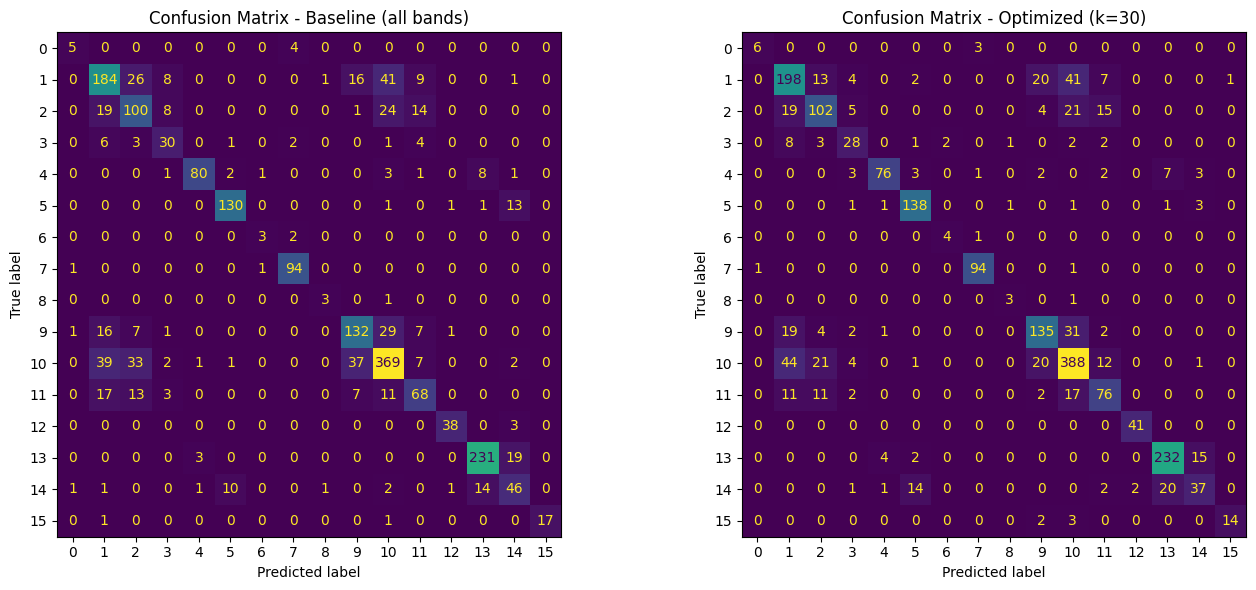

In [111]:

# ----- Confusion matrices side-by-side -----
cm_base = confusion_matrix(y_test, y_pred_base)
cm_opt = confusion_matrix(y_test, y_pred_opt)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp1 = ConfusionMatrixDisplay(cm_base)
disp1.plot(ax=axes[0], cmap='viridis', colorbar=False)
axes[0].set_title("Confusion Matrix - Baseline (all bands)")

disp2 = ConfusionMatrixDisplay(cm_opt)
disp2.plot(ax=axes[1], cmap='viridis', colorbar=False)
axes[1].set_title(f"Confusion Matrix - Optimized (k={best_k})")

plt.tight_layout()
plt.show()



Reconstructing 2D prediction maps (fills background with 0)...


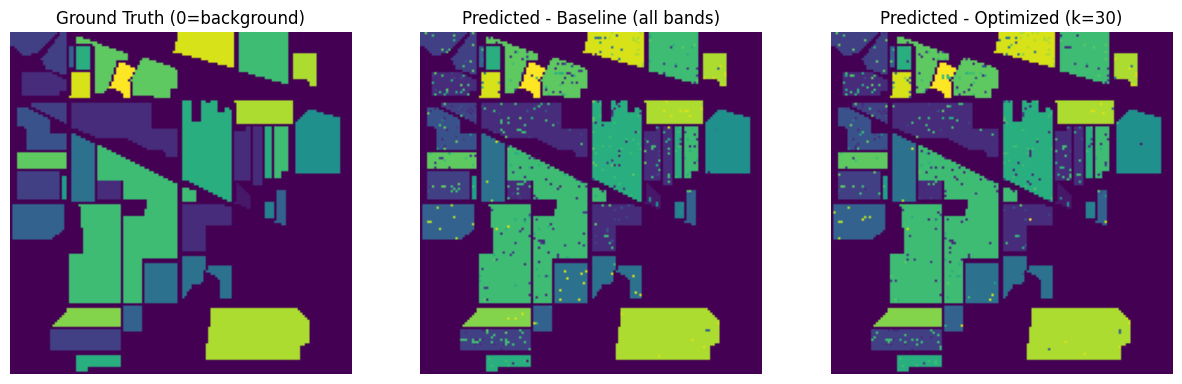

In [112]:

# ----- Reconstruct 2D predicted maps for visualization -----
# This maps predictions back onto the spatial (145,145) grid for qualitative analysis.
print("\nReconstructing 2D prediction maps (fills background with 0)...")
# Predict on all non-background samples
X_all = X_preprocessed  # non-background samples used earlier
y_all_true = y_preprocessed
pred_all_base = model_dt.predict(X_all)
pred_all_opt = best_model.predict(X_all[:, best_bands])

# Build full-size arrays and then reshape
full_pred_base = np.zeros(GT_flat.shape, dtype=int)
full_pred_opt  = np.zeros(GT_flat.shape, dtype=int)
full_true      = GT_flat.copy().astype(int)

full_pred_base[mask] = pred_all_base
full_pred_opt[mask]  = pred_all_opt

map_base = full_pred_base.reshape(GT.shape)
map_opt  = full_pred_opt.reshape(GT.shape)
map_true = full_true.reshape(GT.shape)

# Show true vs baseline vs optimized
fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(map_true, vmin=0)
axes[0].set_title("Ground Truth (0=background)")
axes[0].axis('off')
axes[1].imshow(map_base, vmin=0)
axes[1].set_title("Predicted - Baseline (all bands)")
axes[1].axis('off')
axes[2].imshow(map_opt, vmin=0)
axes[2].set_title(f"Predicted - Optimized (k={best_k})")
axes[2].axis('off')
plt.show()


In [113]:
# ----- Top bands summary -----
print("\nTop selected bands (best_k):")
print(sorted([int(b) for b in best_bands]))

# Final textual analysis printout (concise)
print("\n----- Quick analysis summary -----")
print(f"Baseline (all {X_preprocessed.shape[1]} bands) accuracy: {baseline_acc*100:.2f}%")
print(f"Optimized (k={best_k}) accuracy: {best_model.score(X_test[:, best_bands], y_test)*100:.2f}%")
print(f"Feature reduction: {X_preprocessed.shape[1]} -> {best_k} bands ({(1-best_k/X_preprocessed.shape[1])*100:.1f}% reduction)")



Top selected bands (best_k):
[2, 5, 7, 8, 17, 19, 23, 27, 28, 31, 34, 35, 43, 58, 72, 74, 83, 99, 101, 111, 114, 126, 127, 128, 130, 137, 147, 160, 180, 181]

----- Quick analysis summary -----
Baseline (all 200 bands) accuracy: 74.63%
Optimized (k=30) accuracy: 76.68%
Feature reduction: 200 -> 30 bands (85.0% reduction)


Using bands: [11, 25, 34, 39, 67]
X_train_custom shape: (8199, 5)
X_test_custom shape : (2050, 5)

Custom-band Decision Tree Accuracy: 68.98%

Classification Report:
              precision    recall  f1-score   support

           1      0.700     0.778     0.737         9
           2      0.578     0.559     0.568       286
           3      0.435     0.464     0.449       166
           4      0.543     0.532     0.538        47
           5      0.844     0.784     0.813        97
           6      0.849     0.884     0.866       146
           7      0.833     1.000     0.909         5
           8      0.959     0.969     0.964        96
           9      0.500     0.750     0.600         4
          10      0.591     0.634     0.612       194
          11      0.707     0.678     0.692       491
          12      0.496     0.521     0.508       119
          13      0.857     0.878     0.867        41
          14      0.912     0.905     0.909       253
          15      0.514

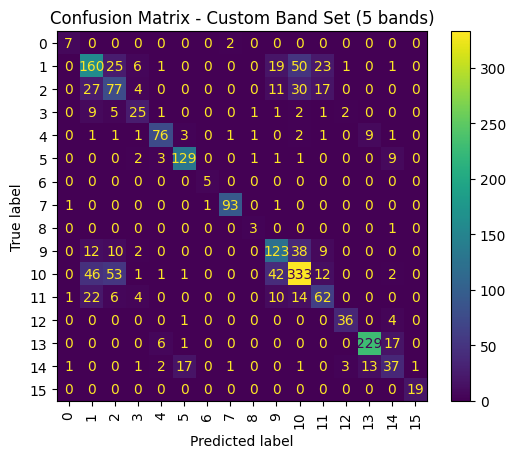

In [114]:
# ------------------------------
# TRAIN & TEST ON CUSTOM BAND SET
# ------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Define your chosen bands (0-based indices)
# custom_bands = [4, 15, 26, 27, 34, 35, 38, 48, 78, 99, 109, 127, 180, 185]
custom_bands = [11, 25, 34, 39, 67]

# Extract only those columns (bands) from your train/test sets
X_train_custom = X_train[:, custom_bands]
X_test_custom  = X_test[:, custom_bands]

print("Using bands:", custom_bands)
print("X_train_custom shape:", X_train_custom.shape)
print("X_test_custom shape :", X_test_custom.shape)

# Train Decision Tree on these selected bands
model_custom = DecisionTreeClassifier(
    criterion="entropy",        # use same criterion you finalized earlier
    max_depth=25,               # you can adjust based on earlier tuning
    random_state=42
)

model_custom.fit(X_train_custom, y_train)

# Predictions
y_pred_custom = model_custom.predict(X_test_custom)

# Evaluation
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"\nCustom-band Decision Tree Accuracy: {acc_custom*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, digits=3, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title(f"Confusion Matrix - Custom Band Set ({len(custom_bands)} bands)")
plt.show()
